# №2 Робота з даними: нормалізація, розбиття даних, тестування. Задача класифікації

Перед початком встановіть бібліотеку <code> split-folders </code> у вашому віртуальному середовищі

In [42]:
from pathlib import Path
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import splitfolders
import tensorflow as tf
from sklearn.metrics import confusion_matrix


# Примусово вимикаємо GPU, щоб усунути помилку CUDA
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

sns.set_theme()

In [43]:
# Define folder
data_dir = splitfolders.Path("CIFAR10-FULL")

In [44]:
# Get class names
classes = sorted(p.name for p in data_dir.iterdir())

classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [45]:
# Count the number of images for each class
class_counts = {}
total_images = 0

for cls in classes:
    cls_path = data_dir / cls
    images = list(cls_path.glob('*.*'))
    count = len(images)
    class_counts[cls] = count
    total_images += count

for cls, count in class_counts.items():
    print(f"Class {cls} has {count} images")

Class airplane has 6000 images
Class automobile has 6000 images
Class bird has 6000 images
Class cat has 6000 images
Class deer has 6000 images
Class dog has 6000 images
Class frog has 6000 images
Class horse has 6000 images
Class ship has 6000 images
Class truck has 6000 images


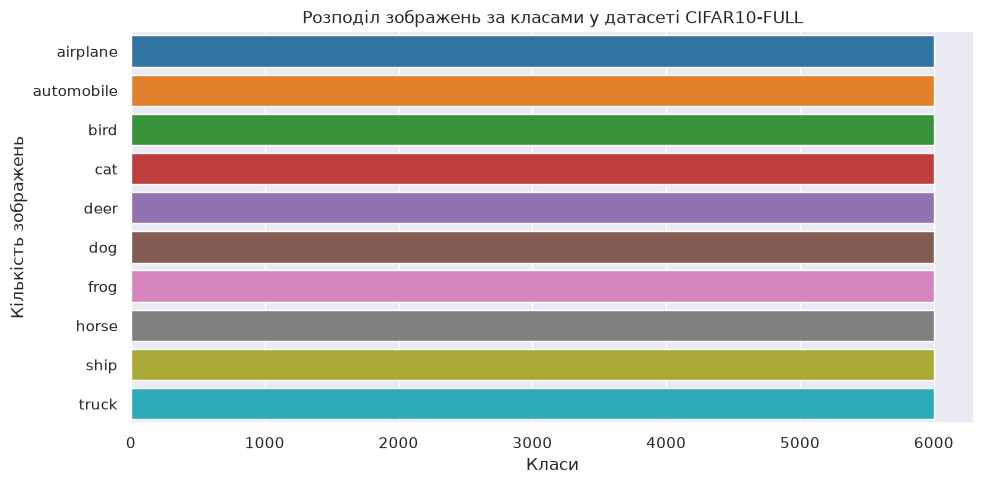

In [46]:
# Visualize the distribution of images per class in the dataset
plt.figure(figsize=(10, 5))
sns.barplot(
    y = list(class_counts.keys()),
    x = list(class_counts.values()),
    palette='tab10',
    hue = list(class_counts.keys()),
)

plt.xlabel('Класи')
plt.ylabel('Кількість зображень')
plt.title('Розподіл зображень за класами у датасеті CIFAR10-FULL')
plt.tight_layout()
plt.show()

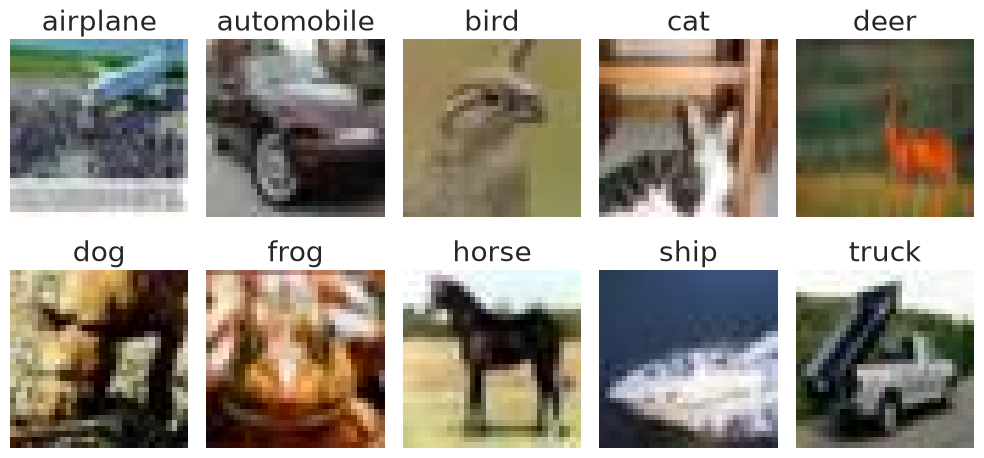

In [47]:
# Display a random sample image for each class in a grid

plt.figure(figsize=(10, 5))

for i, cls in enumerate(classes):
    cls_path = data_dir / cls
    images = list(cls_path.glob("*.*"))

    img_path = np.random.choice(images)
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(cls, fontsize=20)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
output_dir = Path('CIFAR10-SPLIT')

if not output_dir.exists():
    # Split the dataset into train, validation, and test sets
    splitfolders.ratio(
        data_dir,
        output_dir,
        seed = 42,
        ratio = (0.7, 0.15, 0.15)
    )

    print(f"Дані успішно розділені та збережені у папку: {output_dir}")
else:
    print(f"Папка {output_dir} вже існує")

Папка CIFAR10-SPLIT вже існує


In [49]:
BATCH_SIZE = 8

In [50]:
# Load train, validation, and test datasets from the split directory

train_dataset = tf.keras.utils.image_dataset_from_directory('CIFAR10-SPLIT/train', batch_size=BATCH_SIZE, shuffle=True)
val_dataset = tf.keras.utils.image_dataset_from_directory('CIFAR10-SPLIT/val', batch_size=BATCH_SIZE, shuffle=True)
test_dataset = tf.keras.utils.image_dataset_from_directory('CIFAR10-SPLIT/test', batch_size=BATCH_SIZE, shuffle=True)

Found 42000 files belonging to 10 classes.
Found 9000 files belonging to 10 classes.
Found 9000 files belonging to 10 classes.


In [51]:
import tensorflow as tf

print(tf.__version__)
print(tf.keras.__version__)

print(hasattr(tf.keras, "image_dataset_from_directory"))
print(hasattr(tf.keras.utils, "image_dataset_from_directory"))

2.21.0
3.15.0
False
True


In [52]:
for images, labels in train_dataset.take(1):
    print(f"image.shape = {images.shape}")
    print(f"labels.shape = {labels.shape}")
    print(f"labels.dtype = {labels.dtype}")
    print(f"labels: {labels.numpy()}")

image.shape = (8, 256, 256, 3)
labels.shape = (8,)
labels.dtype = <dtype: 'int32'>
labels: [2 9 4 9 1 4 1 0]


In [65]:
# Define a preprocessing function for image datasets

def prepare_dataset(dataset, augmentation=False, one_hot_encoded=False, num_classes=None, cache=False, img_size=(32, 32)):

    # resize
    ds = dataset.map(lambda x, y: (tf.image.resize(x, img_size), y), num_parallel_calls=tf.data.AUTOTUNE)

    # normalization
    ds = ds.map(
        lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augmentation:
        data_augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip('horizontal'),
            tf.keras.layers.RandomRotation(0.2),
            tf.keras.layers.RandomZoom(0.1),
        ])

        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    if one_hot_encoded:
        ds = ds.map(lambda x, y: (x, tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)), num_parallel_calls=tf.data.AUTOTUNE)

    if cache:
        ds = ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

    return ds

In [66]:
IMG_SIZE = (32, 32)

In [67]:
num_classes = len(classes)

In [68]:
# Apply the dataset preparation pipeline to train, validation, and test datasets

train_ds = prepare_dataset(train_dataset, augmentation=True, one_hot_encoded=True, num_classes=num_classes)
val_ds = prepare_dataset(val_dataset, augmentation=False, one_hot_encoded=True, num_classes=num_classes)
test_ds = prepare_dataset(test_dataset, augmentation=False, one_hot_encoded=True, num_classes=num_classes)

In [70]:
# Build a Convolutional Neural Network (CNN) architecture

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax'),

])

In [71]:
# Compile the model
model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy, metrics=['accuracy'])

In [72]:
# Configure an EarlyStopping callback to halt training when validation loss stops improving and restore the best weights
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

In [73]:
# Train the model
history = model.fit(train_ds, validation_data=val_ds, verbose=1, epochs=10, callbacks=[early_stopping], shuffle=False)

Epoch 1/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 124s 23ms/step - accuracy: 0.3272 - loss: 1.8554 - val_accuracy: 0.4283 - val_loss: 1.5941
Epoch 2/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 109s 21ms/step - accuracy: 0.4005 - loss: 1.6613 - val_accuracy: 0.4072 - val_loss: 1.7070
Epoch 3/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 109s 21ms/step - accuracy: 0.4337 - loss: 1.5723 - val_accuracy: 0.4719 - val_loss: 1.4712
Epoch 4/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 107s 20ms/step - accuracy: 0.4541 - loss: 1.5188 - val_accuracy: 0.4596 - val_loss: 1.5449
Epoch 5/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 109s 21ms/step - accuracy: 0.4694 - loss: 1.4791 - val_accuracy: 0.5214 - val_loss: 1.3330
Epoch 6/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 107s 20ms/step - accuracy: 0.4815 - loss: 1.4545 - val_accuracy: 0.5396 - val_loss: 1.2913
Epoch 7/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 113s 21ms/step - accuracy: 0.4873 - loss: 1.4306 - val_accuracy: 0.5248 - val_loss: 1.3370
Epoch 8/10
5250/5250 ━━━━━━━━━━━━━━━━━━━━ 109s 21ms/step - accuracy: 

In [74]:
# Save weights
model.save_weights("cnn.weights.h5")

In [75]:
# Load weights
# model.load_weights("cnn.weights.h5")

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,424 (614.94 KB)

 Trainable params: 52,378 (204.60 KB)

 Non-trainable params: 288 (1.12 KB)

 Optimizer params: 104,758 (409.21 KB)

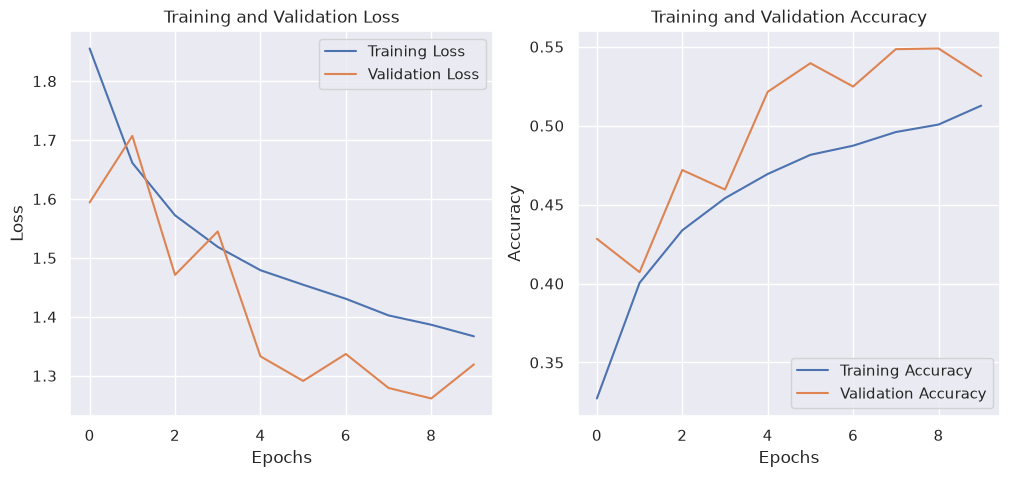

In [76]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs_range = range(len(loss))

plt.figure(figsize=(12, 5))

# 1. Графік функції втрат (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# 2. Графік точності (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


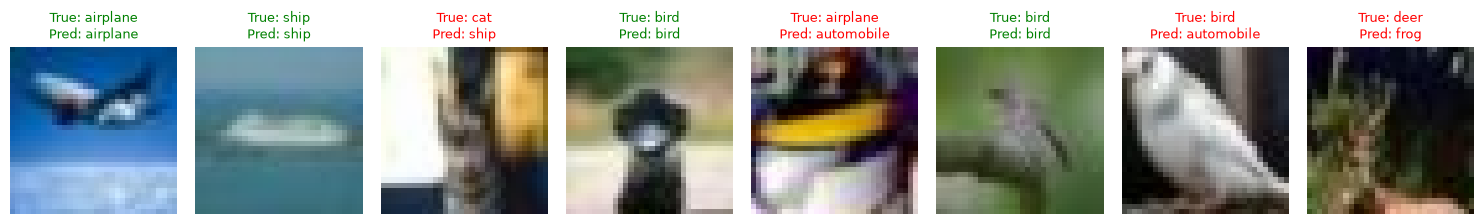

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


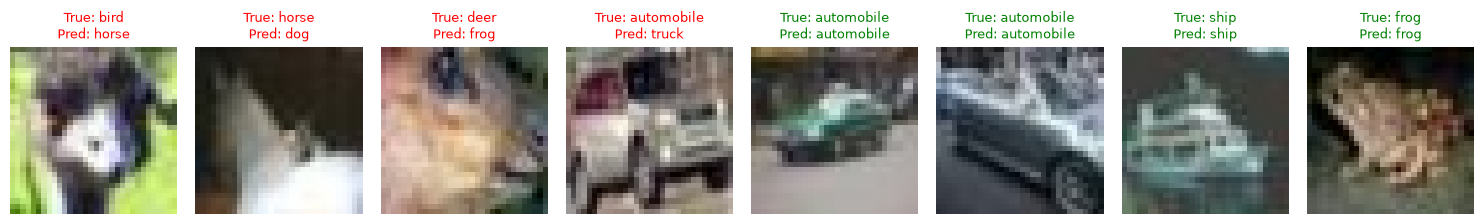

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


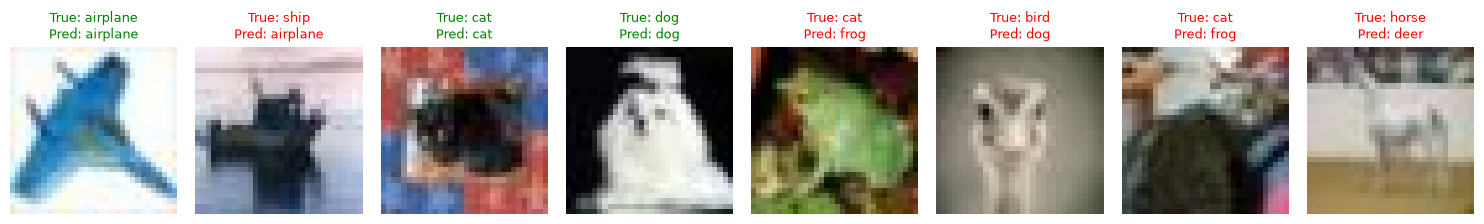

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


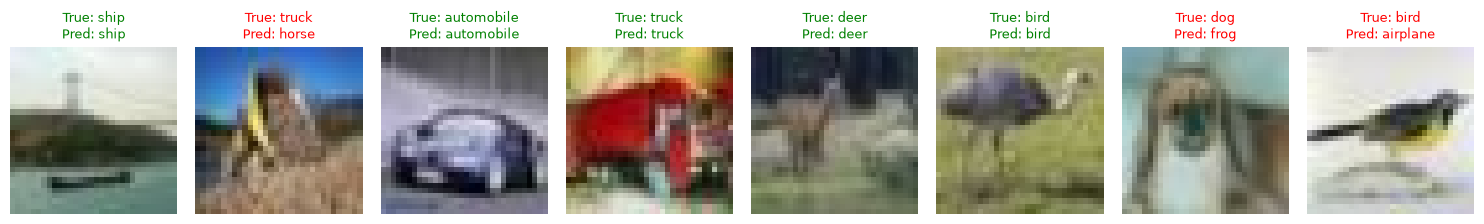

In [77]:
for batch_idx, (images, labels) in enumerate(test_ds.take(4)):
  predictions = model.predict(images)
  num_images = images.shape[0]

  plt.figure(figsize=(15, 12))

  for i in range(num_images):
    # Вираховуємо сітку динамічно під розмір батчу
    plt.subplot(4, 8, i + 1)

    img = images[i].numpy()

    pred_class = np.argmax(predictions[i])
    true_class = np.argmax(labels[i].numpy())

    pred_label_name = classes[pred_class]
    true_label_name = classes[true_class]

    plt.imshow(img)

    if pred_class == true_class:
      color = "green"
    else:
      color = "red"

    title = f"True: {true_label_name}\nPred: {pred_label_name}"
    plt.title(title, color=color, fontsize=9)
    plt.axis("off")

  plt.tight_layout()
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━

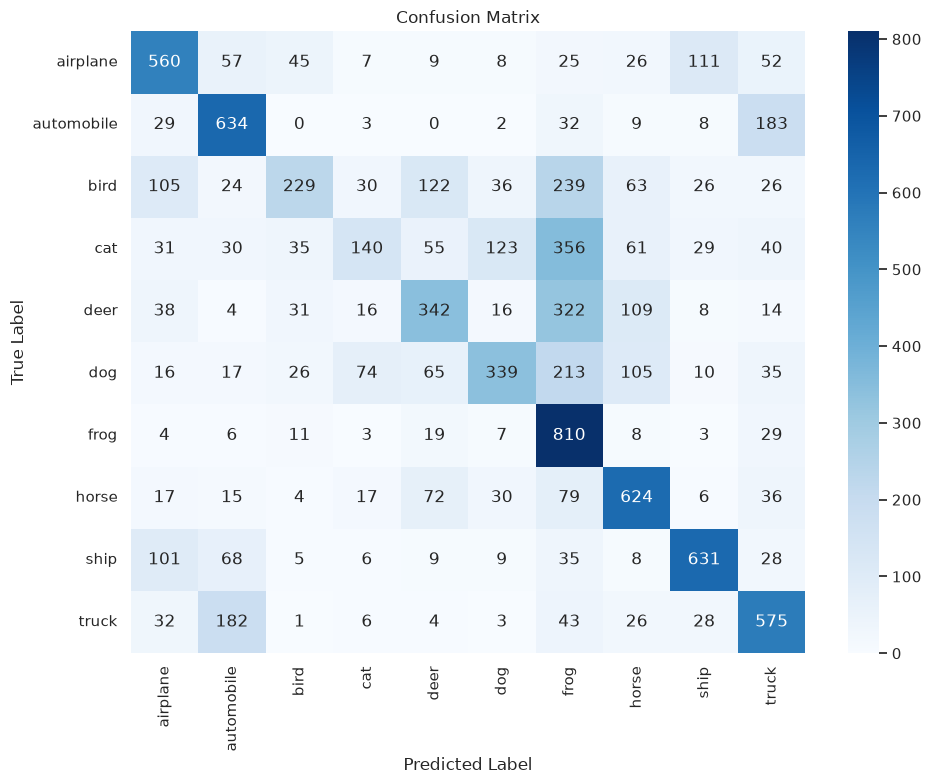

In [78]:
# Collect all true labels and predicted labels from the test dataset
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()